## Exploratory Data Analysis

In this notebook, the Fashionpedia dataset is analyzed exhaustively. Note that the analysis is performed locally and not in Google Colab.

In [2]:
import json
import itertools
import collections
import numpy as np
from matplotlib import pyplot as plt

upto=27

with open('../OR_task2/coco/annotations/instances_attributes_train2020.json', 'r') as file:
    data_train = json.load(file)
    
with open('../OR_task2/coco/annotations/instances_attributes_val2020.json', 'r') as file:
    data_val = json.load(file)

with open('../OR_task2/coco/annotations/info_test2020.json', 'r') as file:
    infos = json.load(file)

In [3]:
id_filename_train = [[entry["id"],entry["file_name"],entry["width"],entry["height"]] for entry in data_train["images"]]
id_filename_val = [[entry["id"],entry["file_name"],entry["width"],entry["height"]] for entry in data_val["images"]]
metrics_images_train = {}
for i in id_filename_train:
    metrics_images_train[i[0]] = i[1:]
metrics_images_val = {}
for i in id_filename_val:
    metrics_images_val[i[0]] = i[1:]  

In [4]:
#Average size and aspect ratio of train and val images
dicts = [metrics_images_train,metrics_images_val]
for d in dicts:
    values = list(d.values())
    w = []
    h = []
    s = []
    ar = []
    for a in values:
        w.append(a[1])
        h.append(a[2])
        s.append(a[1]*a[2])
        ar.append(a[1]*1.0/(1.0*a[2]))
    print("W",np.mean(w))
    print("H",np.mean(h))
    print("S",np.mean(s))
    print("AR",np.mean(ar))
    print()

W 755.2479670341713
H 986.5135567586524
S 734987.8003638516
AR 0.7926327412039755

W 750.7392055267703
H 962.3765112262522
S 705654.493955095
AR 0.8241621427407255



In [5]:
categories = [x["name"] for x in infos["categories"]]
clean_cats = []
for category in categories: ##debloat
    if "," in category:
        clean_cats.append(category.split(",")[0])
    else:
        clean_cats.append(category)

Total annotated images 45623
Train dataset
All categories
total 333401
mean 7.307739517348706
std 3.902161791888715
Reduced categories
total 163060
mean 3.5740744799772046
std 2.059732129346981


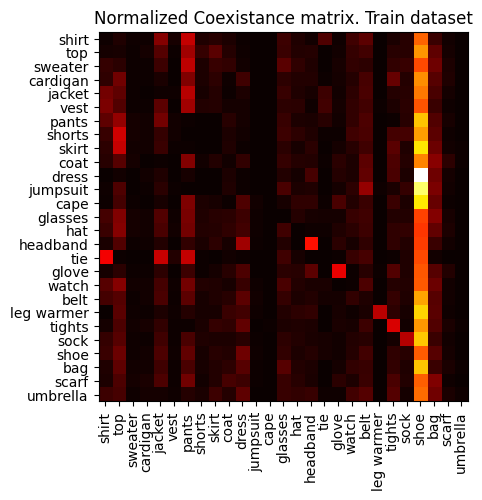

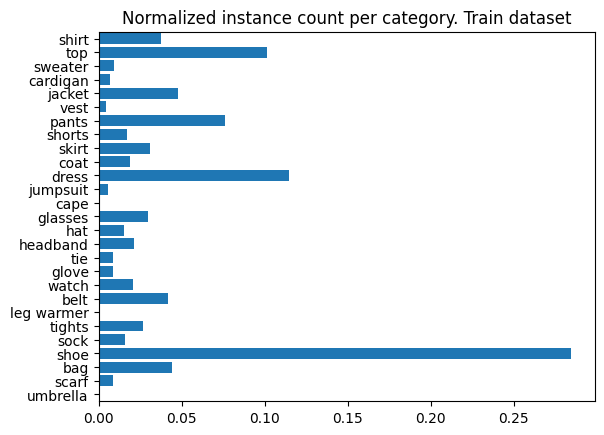


Total annotated images 1158
Val dataset
All categories
total 8781
mean 7.582901554404145
std 3.5531422580132923
Reduced categories
total 4688
mean 4.048359240069084
std 1.8335983202803248


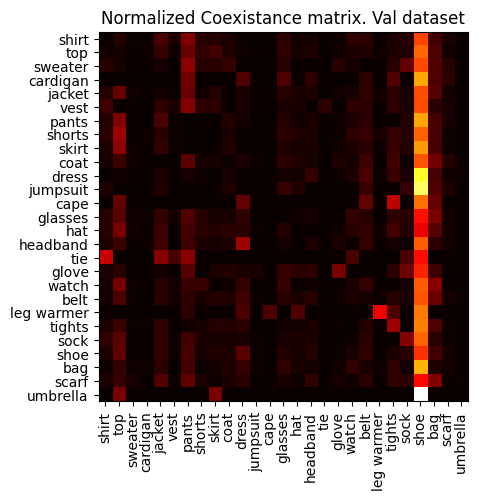

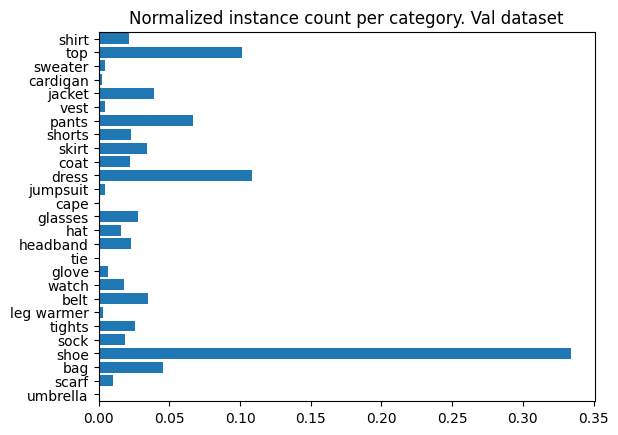

In [6]:
datas = [data_train, data_val]
inf = ["Train dataset","Val dataset"]
counts = []
for k in range(2):
    data = datas[k]
    #PROCESSEM PRIMER TOTES LES ANNOTATIONS
    annotated_images = []
    for entry in data["annotations"]:
        annotated_images.append(entry["image_id"])
    annotated_images = list(set(annotated_images))
    print("Total annotated images",len(annotated_images))
    annotations = {}    
    for i in annotated_images:
        annotations[i] = []
    for entry in data["annotations"]:
        annotations[entry["image_id"]].append(entry)
    anns_x_image=[]
    for key,annon in annotations.items():
        anns_x_image.append(len(annon))
    print(inf[k])
    print("All categories")
    print("total",np.sum(anns_x_image))
    print("mean",np.mean(anns_x_image))
    print("std",np.std(anns_x_image))

    annotations = {}    
    for i in annotated_images:
        annotations[i] = []
    for entry in data["annotations"]:
        if entry["category_id"]>=27: continue
        annotations[entry["image_id"]].append(entry)
    anns_x_image=[]
    for key,annon in annotations.items():
        anns_x_image.append(len(annon))
    print("Reduced categories")
    print("total",np.sum(anns_x_image))
    print("mean",np.mean(anns_x_image))
    print("std",np.std(anns_x_image))
    
    anns_cats = {}    
    for i in annotated_images:
        anns_cats[i] = []
    for entry in data["annotations"]:
        if entry["category_id"]>=27: continue
        anns_cats[entry["image_id"]].append(entry["category_id"])
    
    #coexistance matrix
    cross_categories = list(anns_cats.values())
    coexistance_matrix = np.zeros((upto, upto))
    for elem in cross_categories:
        for i in range(len(elem)):
            for j in range(i+1,len(elem)):
                coexistance_matrix[elem[i]][elem[j]]+=1
                #coexistance_matrix[j][i]+=1
    
    
    #normalized coexistance matrix
    new_coemat = []
    cc = clean_cats[:27]
    for i in range(len(coexistance_matrix)):
        l = coexistance_matrix[i]*1.0
        lT = np.sum(l)*1.0
        v = l/lT
        new_coemat.append(v)
        top3 = list(sorted(zip(v, cc), reverse=True))[:3]
        top3 = [str(y)+str(" ")+str(float(np.round(x*100,1)))+"%" for (x,y) in top3]
        #print(cc[i],top3)
        
    new_coemat = np.array(new_coemat)
    plt.imshow(new_coemat, cmap='hot', interpolation='nearest')
    plt.title("Normalized Coexistance matrix. "+str(inf[k]))
    plt.xticks(range(upto), labels = clean_cats[:27], rotation=90)
    plt.yticks(range(upto), labels = clean_cats[:27], rotation=0)
    plt.show()

    
    #histogram, normalized
    chain = itertools.chain(*cross_categories)
    freq_counter = collections.Counter(chain)
    D = dict(freq_counter)
    D = collections.OrderedDict(sorted(D.items()))
    counts.append(D)
    f = plt.figure()
    ax = f.add_subplot(111)
    #ax.yaxis.tick_right()
    #normalize D
    D = np.array(list(D.values()))*1.0
    Dt = np.sum(D)*1.0
    D /= Dt
    #print(D)

    plt.barh(range(len(D)), D, align='center')
    plt.yticks(range(len(D)), labels = clean_cats[:27], rotation=0)
    plt.ylim(-0.5,27-.5)
    ax.yaxis.set_inverted(True)
    plt.title("Normalized instance count per category. "+str(inf[k]))
    plt.show()
    print()

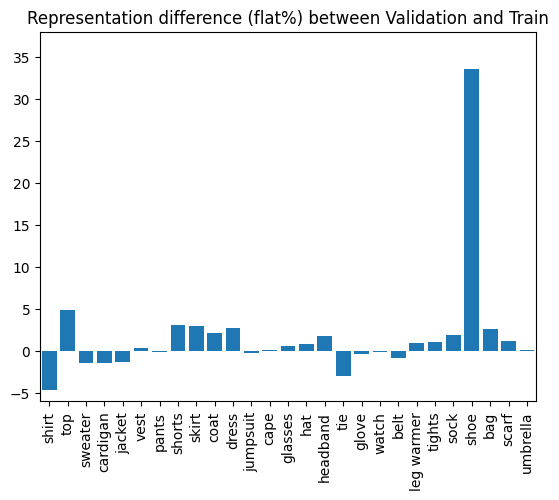

In [7]:
train_ratios = []
for c in counts[0]:
    train_ratios.append(counts[0][c]/45623)
val_ratios = []
for c in counts[1]:
    val_ratios.append(counts[1][c]/1158)
plt.bar(x=clean_cats[:27], height=100*(np.array(val_ratios) - np.array(train_ratios)))
plt.xticks(rotation=90)
plt.title("Representation difference (flat%) between Validation and Train")
plt.ylim(-6,38)
plt.xlim(-0.5,upto-0.5)
plt.show()

In [8]:
def shoelace_formula(x,y):
    correction = x[-1] * y[0] - y[-1]* x[0]
    main_area = np.dot(x[:-1], y[1:]) - np.dot(y[:-1], x[1:])
    return 0.5*np.abs(main_area + correction)

def bboxarea(bbox):
    a = (bbox[2]*bbox[3])
    return np.abs(a)

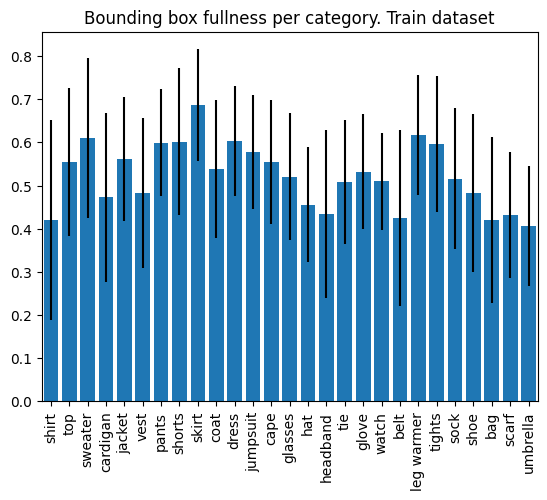

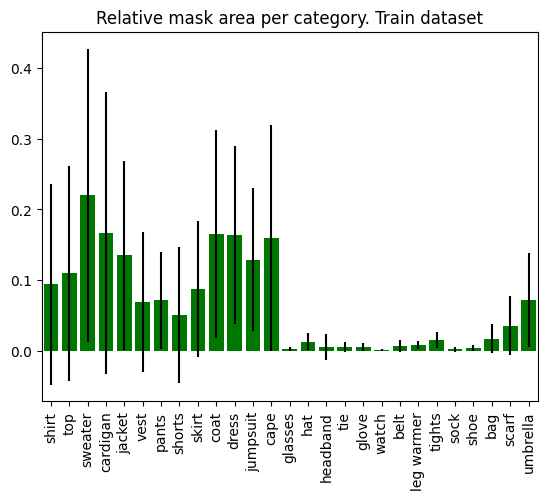

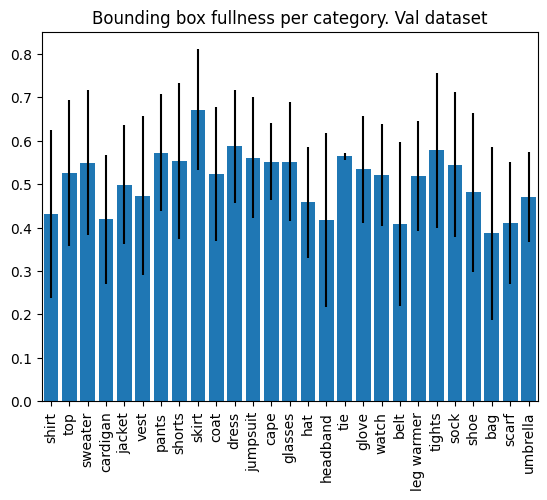

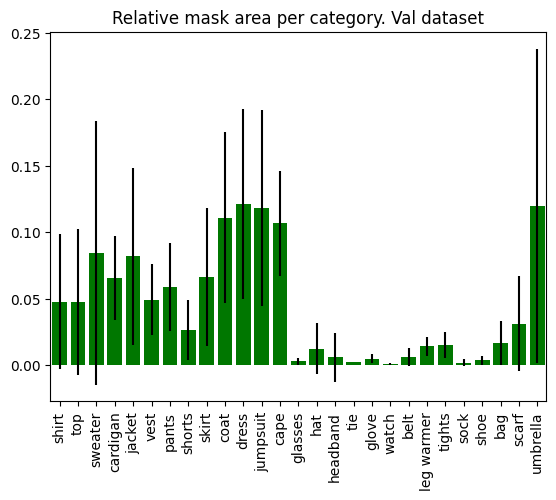

In [9]:
datas = [data_train, data_val]
inf = ["Train dataset","Val dataset"]
z = 0

rel_mask_area = [] #for last analysis

for z in range(2):
    data = datas[z]
    info = inf[z]
    area_values = {}
    size_ratio_values = {}
    fragments = {}

    for clean_cat in clean_cats[:27]:
        area_values[clean_cat] = []
        fragments[clean_cat] = []
        size_ratio_values[clean_cat] = []
    #print(area_values)

    for annot in data["annotations"]:
        category_id = annot["category_id"]
        if category_id>=27: continue
        
        category = clean_cats[category_id]
        
        #potentially corrupt files
        if type(annot["segmentation"])!=type([]):
            #print(annot["segmentation"])
            continue
        #print(annot["category_id"])
        #print(clean_cats[:27][annot["category_id"]])
        bbox = bboxarea(annot["bbox"])
        #print("bbox",bbox)
        area = annot["area"]
        #print("precalc area",area)
        
        imgdata = dicts[z][annot["image_id"]] #recover data from imageid+metadata table
        imgsize = imgdata[1]*imgdata[2] #width x height

        area_values[category].append(area/bbox)
        size_ratio_values[category].append(area/imgsize)

        continue #we don't need that right now
        i+=1
        for mask in annot["segmentation"]:
            xs, ys = [], []

            for v in range(len(mask)):
                if v%2==0:
                    xs.append(mask[v])
                else:
                    ys.append(mask[v])
            xs.append(xs[0])
            ys.append(ys[0])
            '''
            plt.figure()
            plt.plot(xs, ys) 
            plt.axis('scaled')
            plt.show()
            '''
            if len(xs)==len(ys):
                print("shoelace",shoelace_formula(xs,ys))
        print()
        #if i > 15: break
    mean_area_ratios = [np.mean(v) for k,v in area_values.items()]
    std_area_ratios = [np.std(v) for k,v in area_values.items()]

    plt.bar(clean_cats[:27],mean_area_ratios,yerr=std_area_ratios)
    plt.xticks(range(len(D)), labels = clean_cats[:27], rotation=90)
    plt.xlim(-0.5,upto-.5)
    plt.title("Bounding box fullness per category. "+str(info))
    plt.show()
    
    mean_area_ratios = [np.mean(v) for k,v in size_ratio_values.items()]
    std_area_ratios = [np.std(v) for k,v in size_ratio_values.items()]
    
    rel_mask_area.append(mean_area_ratios)
    plt.bar(clean_cats[:27],mean_area_ratios,yerr=std_area_ratios,color="#007700")
    plt.xticks(range(len(D)), labels = clean_cats[:27], rotation=90)
    plt.xlim(-0.5,upto-.5)
    plt.title("Relative mask area per category. "+str(info))
    plt.show()

0.6065091381624446


Text(9.8, 0.04, '$R^2=0.5435$')

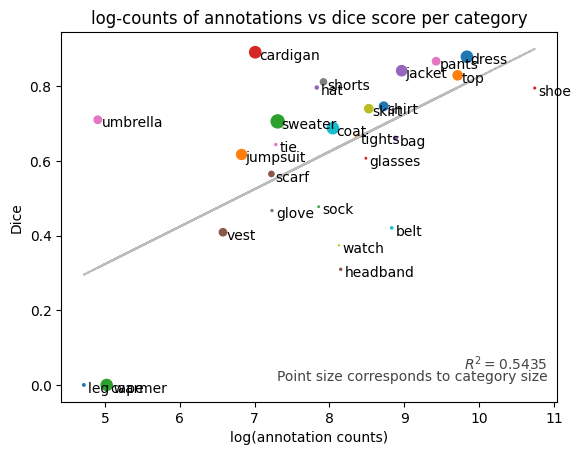

In [11]:
from scipy.stats import linregress
from matplotlib import cm


conts = list(counts[0].values())
sizes = np.array(rel_mask_area[0])

dumps=""

with open("../lastgitpull/results/results_best/deeplabv3+_384_384_5e-05_5_pretrained_data_aug_1_validation_metrics.json") as f:
    dumps = json.load(f)

dice = dumps[-1]["dice_per_class"][1:]

coef = np.polyfit(np.log(conts),dice,1)
poly1d_fn = np.poly1d(coef)
[slope,intercept,rvalue,pvalue,stderr]=linregress(np.log(conts),dice) 
print(rvalue)

a = cm.tab10(range(10))

plt.scatter(np.log(conts),dice,s=400*sizes,c = np.concatenate([a,a,a])[:-3])
plt.plot(np.log(conts),poly1d_fn(np.log(conts)), '--',c="#bbb")
plt.xlabel("log(annotation counts)")
plt.ylabel("Dice")
plt.title("log-counts of annotations vs dice score per category")

for i in range(27):
    plt.annotate(clean_cats[i], (np.log(conts[i])+0.05,dice[i]-0.02))

plt.annotate("Point size corresponds to category size", (7.3,0.01),c="#444")
plt.annotate("$R^2=$"+str(np.roundrvalue), (9.8,0.04),c="#444")
#plt.scatter(conts,dice,s=400*sizes)